# Special-Token Training — Presentation Plots

Four focused plots:
1. **Branch means** — mean baseline vs mean best loss for 4 (persona × style) branches
2. **Topics for a branch** — baseline vs best loss per held-out topic (slope chart)
3. **Training history** — train/val curves for one run
4. **Token-count trend** — mean best loss vs num_special_tokens for a branch

Architecture:
- `df_runs` — one row per run from `runs_summary.jsonl`
- `df_history` — one row per training checkpoint (from `run_summary.json` files)
- `df_paired` — one row per trained run with its matching baseline attached

## 1. Imports & Setup

In [11]:
from pathlib import Path
import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional, Tuple

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

# Resolve paths whether notebook is launched from repo root or special-token/
NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / 'special-token' / 'data' / 'runs').exists():
    BASE_DIR = NOTEBOOK_DIR / 'special-token'
elif (NOTEBOOK_DIR / 'data' / 'runs').exists():
    BASE_DIR = NOTEBOOK_DIR
else:
    BASE_DIR = NOTEBOOK_DIR.parent

RUNS_DIR     = BASE_DIR / 'data' / 'runs'
RUNS_SUMMARY = RUNS_DIR / 'runs_summary.jsonl'
assert RUNS_SUMMARY.exists(), f'Missing: {RUNS_SUMMARY}'
print(f'BASE_DIR : {BASE_DIR}')
print(f'RUNS_DIR : {RUNS_DIR}')

BASE_DIR : /Users/emmamora/Documents/GitHub/llm-wm/special-token
RUNS_DIR : /Users/emmamora/Documents/GitHub/llm-wm/special-token/data/runs


## 2. Build `df_runs`

One row per run. Adds `branch_label` (e.g. `Emma | PickOne`) and `config_label` (e.g. `tok15 | after_context | shared_position`).

In [12]:
df_all = pd.read_json(RUNS_SUMMARY, lines=True)

df_all['branch_label'] = df_all['base_persona_id'] + ' | ' + df_all['style_id']
df_all['config_label'] = (
    'tok' + df_all['num_special_tokens'].astype(str)
    + ' | ' + df_all['token_placement']
    + ' | ' + df_all['position_mode']
)

df_runs      = df_all[~df_all['is_baseline']].copy().reset_index(drop=True)
df_baselines = df_all[ df_all['is_baseline']].copy().reset_index(drop=True)

print(f'Total rows   : {len(df_all)}')
print(f'Trained runs : {len(df_runs)}')
print(f'Baselines    : {len(df_baselines)}')
print(f'Personas     : {sorted(df_all["base_persona_id"].unique())}')
print(f'Styles       : {sorted(df_all["style_id"].unique())}')
print(f'Topics       : {sorted(df_all["held_out_topic_id"].unique())}')
print(f'Token counts : {sorted(df_all["num_special_tokens"].unique())}')
df_runs.head(3)

Total rows   : 251
Trained runs : 210
Baselines    : 41
Personas     : ['Emma', 'Maria']
Styles       : ['PickOne', 'SoBasically', 'WhatIf']
Topics       : ['career_learning', 'creative_projects', 'current_events_civic', 'ethics_decision_making', 'health_wellbeing', 'personal_finance_basics', 'productivity_habits', 'relationships_communication', 'tech_everyday', 'travel_living_abroad']
Token counts : [np.int64(0), np.int64(1), np.int64(3), np.int64(5), np.int64(10), np.int64(15)]


,run_name,base_persona_id,style_id,held_out_topic_id,num_special_tokens,token_placement,position_mode,learning_rate,weight_decay,batch_size,num_epochs,n_train_examples,n_val_examples,baseline_val_loss,best_val_loss,final_val_loss,is_baseline,branch_label,config_label
0,Emma__SoBasically__heldout_career_learning__to...,Emma,SoBasically,career_learning,1,after_context,default,0.0005,0,1,3,252,28,2.1393,1.9283,1.9283,False,Emma | SoBasically,tok1 | after_context | default
1,Emma__SoBasically__heldout_career_learning__to...,Emma,SoBasically,career_learning,3,before_context,shared_position,0.0005,0,1,3,252,28,2.1334,2.1334,2.1334,False,Emma | SoBasically,tok3 | before_context | shared_position
2,Emma__SoBasically__heldout_career_learning__to...,Emma,SoBasically,career_learning,3,before_context,default,0.0005,0,1,3,252,28,2.1334,2.1334,2.1334,False,Emma | SoBasically,tok3 | before_context | default


## 3. Build `df_history`

One row per training checkpoint, reading each run folder's `run_summary.json`.

In [13]:
records = []
for run_dir in sorted(RUNS_DIR.iterdir()):
    p = run_dir / 'run_summary.json'
    if not p.exists():
        continue
    with open(p) as f:
        data = json.load(f)
    if not data['train_history']:  # skip baseline runs (empty history)
        continue
    cfg      = data['config']
    meta     = data['metadata']
    base_val = meta['baseline_val_loss']
    for step in data['train_history']:
        records.append({
            'run_name'           : cfg['run_name'],
            'base_persona_id'    : cfg['base_persona_id'],
            'style_id'           : cfg['style_id'],
            'held_out_topic_id'  : cfg['held_out_topic_id'],
            'num_special_tokens' : cfg['num_special_tokens'],
            'token_placement'    : cfg['token_placement'],
            'position_mode'      : cfg['position_mode'],
            'global_step'        : step['global_step'],
            'base_train_loss'    : step['base_train_loss'],
            'full_train_loss'    : step['full_train_loss'],
            'val_loss'           : step['val_loss'],
            'baseline_val_loss'  : base_val,
        })

df_history = pd.DataFrame(records)
print(f'df_history : {len(df_history):,} checkpoint rows across {df_history["run_name"].nunique()} runs')
df_history.head(3)

df_history : 7,980 checkpoint rows across 210 runs


,run_name,base_persona_id,style_id,held_out_topic_id,num_special_tokens,token_placement,position_mode,global_step,base_train_loss,full_train_loss,val_loss,baseline_val_loss
0,Emma__PickOne__heldout_career_learning__tok10_...,Emma,PickOne,career_learning,10,after_context,shared_position,1,1.6181,1.6181,1.9642,1.9642
1,Emma__PickOne__heldout_career_learning__tok10_...,Emma,PickOne,career_learning,10,after_context,shared_position,20,1.8639,1.8639,1.9506,1.9642
2,Emma__PickOne__heldout_career_learning__tok10_...,Emma,PickOne,career_learning,10,after_context,shared_position,40,1.6846,1.6846,1.9218,1.9642


## 4. Build `df_paired`

One row per trained run. Attaches the matching baseline val loss via explicit join.

**Pairing rule**: same `(base_persona_id, style_id, held_out_topic_id)` + `num_special_tokens=0` + `token_placement=after_context` + `position_mode=default`.

In [14]:
BL_KEY = ['base_persona_id', 'style_id', 'held_out_topic_id']

# Canonical baseline: tok=0, after_context, default
df_bl = (
    df_baselines[
        (df_baselines['num_special_tokens'] == 0) &
        (df_baselines['token_placement']    == 'after_context') &
        (df_baselines['position_mode']      == 'default')
    ]
    .sort_values('run_name')
    .drop_duplicates(subset=BL_KEY, keep='last')
    [BL_KEY + ['best_val_loss']]
    .rename(columns={'best_val_loss': 'matched_baseline'})
)

df_paired = df_runs.merge(df_bl, on=BL_KEY, how='left')
# Fallback: use the stored baseline_val_loss column for runs without a matched baseline
df_paired['matched_baseline'] = df_paired['matched_baseline'].fillna(df_paired['baseline_val_loss'])

df_paired['trained_best_val_loss']  = df_paired['best_val_loss']
df_paired['trained_final_val_loss'] = df_paired['final_val_loss']
df_paired['improvement_abs']        = df_paired['matched_baseline'] - df_paired['trained_best_val_loss']
df_paired['improvement_rel']        = df_paired['improvement_abs'] / df_paired['matched_baseline'] * 100

PAIRED_COLS = [
    'base_persona_id', 'style_id', 'held_out_topic_id',
    'num_special_tokens', 'token_placement', 'position_mode',
    'branch_label', 'config_label',
    'matched_baseline', 'trained_best_val_loss', 'trained_final_val_loss',
    'improvement_abs', 'improvement_rel',
]
df_paired = df_paired[PAIRED_COLS].copy()

print(f'df_paired : {len(df_paired)} trained runs')
print(f'Improved  : {(df_paired["improvement_abs"] > 0).sum()} / {len(df_paired)}')
df_paired.head(4)

df_paired : 210 trained runs
Improved  : 209 / 210


,base_persona_id,style_id,held_out_topic_id,num_special_tokens,token_placement,position_mode,branch_label,config_label,matched_baseline,trained_best_val_loss,trained_final_val_loss,improvement_abs,improvement_rel
0,Emma,SoBasically,career_learning,1,after_context,default,Emma | SoBasically,tok1 | after_context | default,2.1334,1.9283,1.9283,0.2051,9.6134
1,Emma,SoBasically,career_learning,3,before_context,shared_position,Emma | SoBasically,tok3 | before_context | shared_position,2.1334,2.1334,2.1334,0.0000,0.0000
2,Emma,SoBasically,career_learning,3,before_context,default,Emma | SoBasically,tok3 | before_context | default,2.1334,2.1334,2.1334,0.0000,0.0000
3,Emma,SoBasically,career_learning,1,after_context,shared_position,Emma | SoBasically,tok1 | after_context | shared_position,2.1334,1.9283,1.9283,0.2051,9.6134


## 5. Plotting Functions

In [15]:
# ───────────────────────────────────────────────────────────────────────────────
# PLOT 1  Branch means — 4 (persona × style) branches
# ───────────────────────────────────────────────────────────────────────────────

BRANCH_ORDER = ['Emma | PickOne', 'Emma | WhatIf', 'Maria | PickOne', 'Maria | WhatIf']

def plot_branch_means(
    df_paired,
    *,
    token_placement: str = 'after_context',
    position_mode:   str = 'shared_position',
    num_special_tokens: int = 15,
    figsize: Tuple[int, int] = (9, 5),
    title: Optional[str] = None,
) -> None:
    """Grouped bar: mean baseline vs mean best val loss for 4 branches.
    Both means are averaged over held-out-topic folds."""
    sub = df_paired[
        (df_paired['token_placement']    == token_placement) &
        (df_paired['position_mode']      == position_mode)   &
        (df_paired['num_special_tokens'] == num_special_tokens)
    ]
    if sub.empty:
        print(f'[plot_branch_means] No data for {token_placement}/{position_mode}/tok{num_special_tokens}')
        return

    agg = (
        sub.groupby('branch_label', as_index=False)
           .agg(
               mean_baseline=('matched_baseline',      'mean'),
               mean_best    =('trained_best_val_loss',  'mean'),
               n_topics     =('held_out_topic_id', 'nunique'),
           )
    )
    order = [b for b in BRANCH_ORDER if b in agg['branch_label'].values]
    agg = agg.set_index('branch_label').reindex(order).reset_index()

    x, w = np.arange(len(agg)), 0.35
    fig, ax = plt.subplots(figsize=figsize)
    b1 = ax.bar(x - w/2, agg['mean_baseline'], w, label='Mean baseline (tok=0)')
    b2 = ax.bar(x + w/2, agg['mean_best'],     w, label=f'Mean best (tok{num_special_tokens})')
    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(agg['branch_label'], fontsize=11)
    ax.set_ylabel('Mean val loss  (↓ better)', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)
    if title is None:
        title = (
            f'Mean baseline vs mean best val loss by branch\n'
            f'tok={num_special_tokens}  |  {token_placement}  |  {position_mode}  '
            f'(averaged over held-out-topic folds)'
        )
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()


# ───────────────────────────────────────────────────────────────────────────────
# PLOT 2  Per-topic slope chart for one branch
# ───────────────────────────────────────────────────────────────────────────────

def plot_topics_for_branch(
    df_paired,
    *,
    persona: str,
    style:   str,
    token_placement:    str = 'after_context',
    position_mode:      str = 'shared_position',
    num_special_tokens: int = 15,
    figsize: Tuple[int, int] = (13, 5),
    title: Optional[str] = None,
) -> None:
    """Slope chart: baseline vs best val loss for each held-out topic."""
    sub = df_paired[
        (df_paired['base_persona_id']    == persona)          &
        (df_paired['style_id']           == style)            &
        (df_paired['token_placement']    == token_placement)  &
        (df_paired['position_mode']      == position_mode)    &
        (df_paired['num_special_tokens'] == num_special_tokens)
    ].sort_values('held_out_topic_id').copy()

    if sub.empty:
        print(f'[plot_topics_for_branch] No data for {persona}/{style} tok{num_special_tokens} {token_placement} {position_mode}')
        return

    topics, x = sub['held_out_topic_id'].tolist(), np.arange(len(sub))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    c_improved, c_regressed = colors[2], colors[3]  # green, red in default cycle

    fig, ax = plt.subplots(figsize=figsize)
    for xi, row in enumerate(sub.itertuples()):
        c = c_improved if row.trained_best_val_loss < row.matched_baseline else c_regressed
        ax.plot([xi - 0.12, xi + 0.12],
                [row.matched_baseline, row.trained_best_val_loss],
                color=c, lw=1.8, zorder=2)

    ax.scatter(x - 0.12, sub['matched_baseline'],      s=90, zorder=3,
               marker='D', label='Baseline val loss')
    ax.scatter(x + 0.12, sub['trained_best_val_loss'], s=90, zorder=3,
               marker='o', label=f'Best val loss (tok{num_special_tokens})')

    mb  = sub['matched_baseline'].mean()
    mbe = sub['trained_best_val_loss'].mean()
    ax.axhline(mb,  lw=1.2, ls=':', alpha=0.8, label=f'Mean baseline  {mb:.3f}')
    ax.axhline(mbe, lw=1.2, ls=':', alpha=0.8, label=f'Mean best       {mbe:.3f}')

    n_improved = (sub['trained_best_val_loss'] < sub['matched_baseline']).sum()
    ax.set_xticks(x)
    ax.set_xticklabels([t.replace('_', ' ') for t in topics], rotation=30, ha='right', fontsize=10)
    ax.set_ylabel('Val loss  (↓ better)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.25)
    if title is None:
        title = (
            f'{persona} | {style}  —  baseline vs best val loss per held-out topic\n'
            f'tok={num_special_tokens}  |  {token_placement}  |  {position_mode}  '
            f'({n_improved}/{len(sub)} topics improved  |  mean drop {mb - mbe:.3f})'
        )
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()


# ───────────────────────────────────────────────────────────────────────────────
# PLOT 3  Training history for one run
# ───────────────────────────────────────────────────────────────────────────────

def plot_training_history(
    df_history,
    *,
    persona:            str,
    style:              str,
    held_out_topic:     str,
    token_placement:    str = 'after_context',
    position_mode:      str = 'shared_position',
    num_special_tokens: int = 15,
    figsize: Tuple[int, int] = (11, 5),
    title: Optional[str] = None,
) -> None:
    """Training curves: train loss (solid), val loss (solid),
    baseline val loss (dashed). The token learns when val drops below baseline."""
    sub = df_history[
        (df_history['base_persona_id']    == persona)          &
        (df_history['style_id']           == style)            &
        (df_history['held_out_topic_id']  == held_out_topic)   &
        (df_history['token_placement']    == token_placement)  &
        (df_history['position_mode']      == position_mode)    &
        (df_history['num_special_tokens'] == num_special_tokens)
    ].sort_values('global_step')

    if sub.empty:
        print(f'[plot_training_history] No history for {persona}/{style}/{held_out_topic} '
              f'tok{num_special_tokens} {token_placement} {position_mode}')
        return

    run_name = sorted(sub['run_name'].unique())[-1]  # latest if duplicates
    sub = sub[sub['run_name'] == run_name]

    baseline_val = sub['baseline_val_loss'].iloc[0]
    best_val     = sub['val_loss'].min()
    best_step    = sub.loc[sub['val_loss'].idxmin(), 'global_step']

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(sub['global_step'], sub['full_train_loss'],
            label='Train loss', lw=2, marker='o', ms=3.5)
    ax.plot(sub['global_step'], sub['val_loss'],
            label='Val loss',   lw=2, marker='s', ms=3.5)
    ax.axhline(baseline_val, lw=1.4, ls='--',
               label=f'Baseline val loss  {baseline_val:.4f}')
    ax.annotate(
        f'best={best_val:.4f}',
        xy=(best_step, best_val), xytext=(12, 12), textcoords='offset points',
        fontsize=9, arrowprops=dict(arrowstyle='->', lw=1.2),
    )
    ax.set_xlabel('Global step', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.legend(fontsize=9, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    if title is None:
        title = (
            f'Training history — {persona} | {style} | {held_out_topic.replace("_", " ")}\n'
            f'tok={num_special_tokens}  |  {token_placement}  |  {position_mode}  '
            f'(improvement: {baseline_val - best_val:.4f})'
        )
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()


# ───────────────────────────────────────────────────────────────────────────────
# PLOT 4  Token-count trend for one branch
# ───────────────────────────────────────────────────────────────────────────────

def plot_token_count_trend(
    df_paired,
    *,
    persona:         str,
    style:           str,
    token_placement: str = 'after_context',
    position_mode:   str = 'shared_position',
    figsize: Tuple[int, int] = (9, 5),
    title: Optional[str] = None,
) -> None:
    """Line plot: mean best val loss vs num_special_tokens.
    Baseline mean shown as a dashed horizontal line.
    Both averaged over held-out-topic folds."""
    sub = df_paired[
        (df_paired['base_persona_id'] == persona)          &
        (df_paired['style_id']        == style)            &
        (df_paired['token_placement'] == token_placement)  &
        (df_paired['position_mode']   == position_mode)
    ]
    if sub.empty:
        print(f'[plot_token_count_trend] No data for {persona}/{style} {token_placement} {position_mode}')
        return

    agg = (
        sub.groupby('num_special_tokens', as_index=False)
           .agg(
               mean_baseline=('matched_baseline',      'mean'),
               mean_best    =('trained_best_val_loss',  'mean'),
               n_topics     =('held_out_topic_id', 'nunique'),
           )
           .sort_values('num_special_tokens')
    )
    baseline_mean = agg['mean_baseline'].mean()

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(agg['num_special_tokens'], agg['mean_best'],
            lw=2.2, marker='o', ms=7, label='Mean best val loss (trained)')
    for row in agg.itertuples():
        ax.text(row.num_special_tokens, row.mean_best - 0.003,
                f'{row.mean_best:.3f}', ha='center', va='top', fontsize=8)
    ax.axhline(baseline_mean, lw=1.4, ls='--',
               label=f'Mean baseline (tok=0)  {baseline_mean:.3f}')
    ax.set_xlabel('Number of special tokens', fontsize=11)
    ax.set_ylabel('Mean val loss over topics  (↓ better)', fontsize=11)
    ax.set_xticks(sorted(sub['num_special_tokens'].unique()))
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    if title is None:
        title = (
            f'Token-count trend — {persona} | {style}\n'
            f'{token_placement}  |  {position_mode}  (averaged over held-out-topic folds)'
        )
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()


print('Loaded: plot_branch_means, plot_topics_for_branch, plot_training_history, plot_token_count_trend')

Loaded: plot_branch_means, plot_topics_for_branch, plot_training_history, plot_token_count_trend


## 6. Plot 1 — Branch Means

**Slide 3** — Branch-level aggregation. Mean baseline vs mean best val loss for each (persona, style) branch, averaged over all held-out-topic folds.

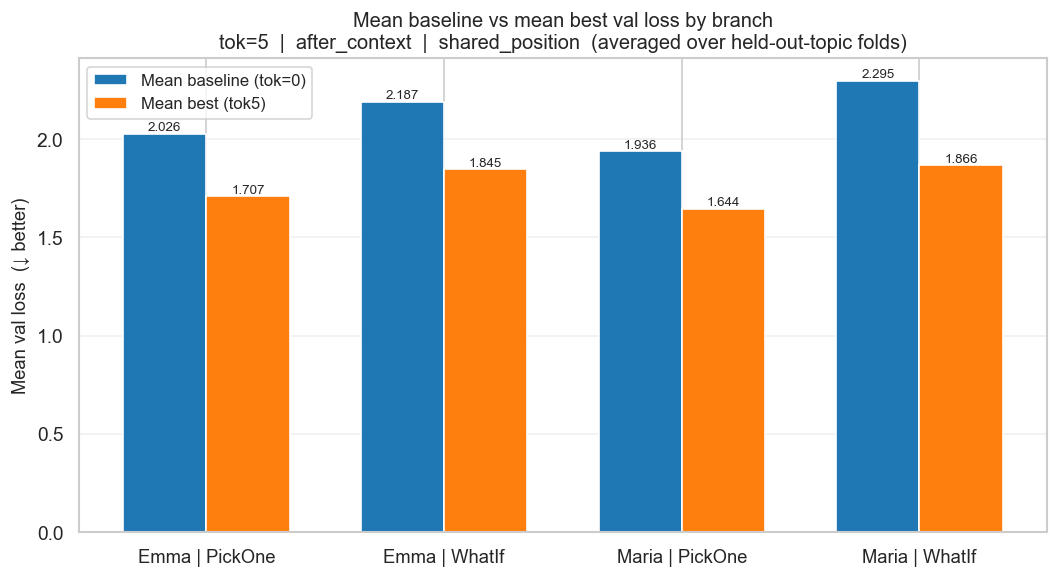

In [22]:
plot_branch_means(
    df_paired,
    token_placement    = 'after_context',
    position_mode      = 'shared_position',
    num_special_tokens = 5,
)

## 7. Plot 2 — Per-Topic Slope Chart

**Slide 2** — Cross-topic consistency. For one branch: baseline (grey ◆) vs trained (green ●) per topic. Downward slope = improvement. Green line = improved; red = regressed.

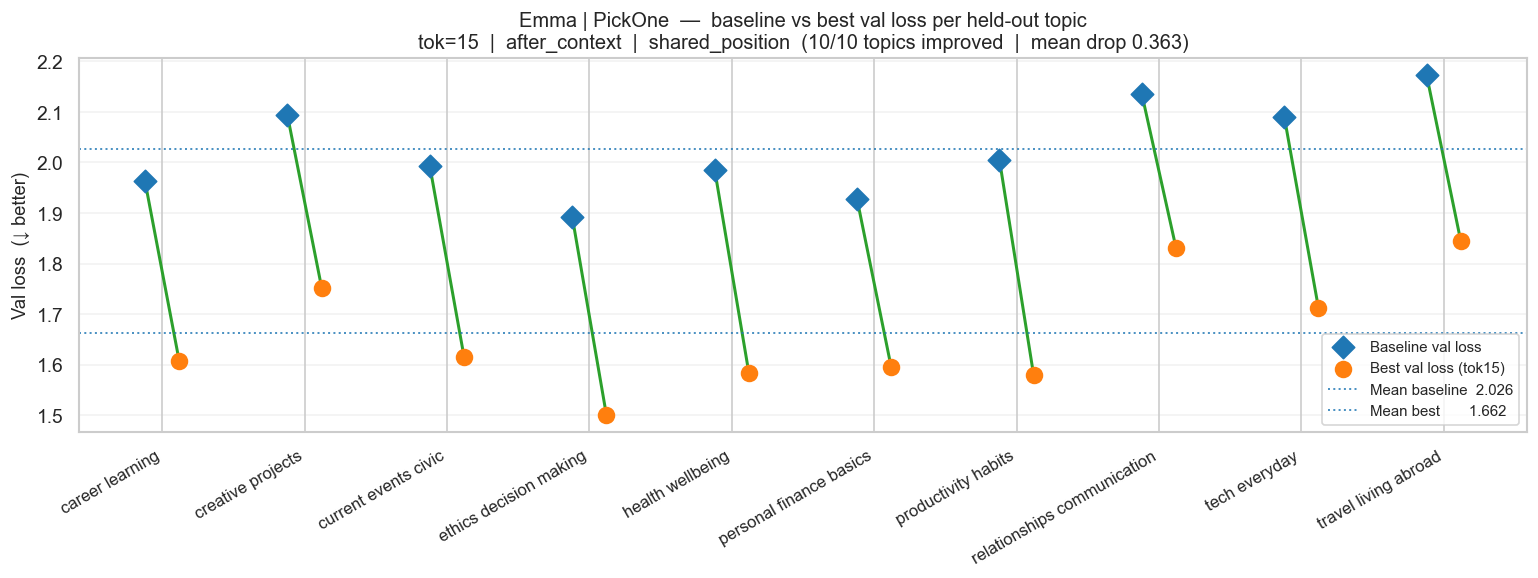

In [17]:
plot_topics_for_branch(
    df_paired,
    persona            = 'Emma',
    style              = 'PickOne',
    token_placement    = 'after_context',
    position_mode      = 'shared_position',
    num_special_tokens = 15,
)

## 8. Plot 3 — Training History

**Slide 1** — Training dynamics. Train loss (blue), val loss (orange), baseline (dashed red). The gap between dashed and orange is the gain.

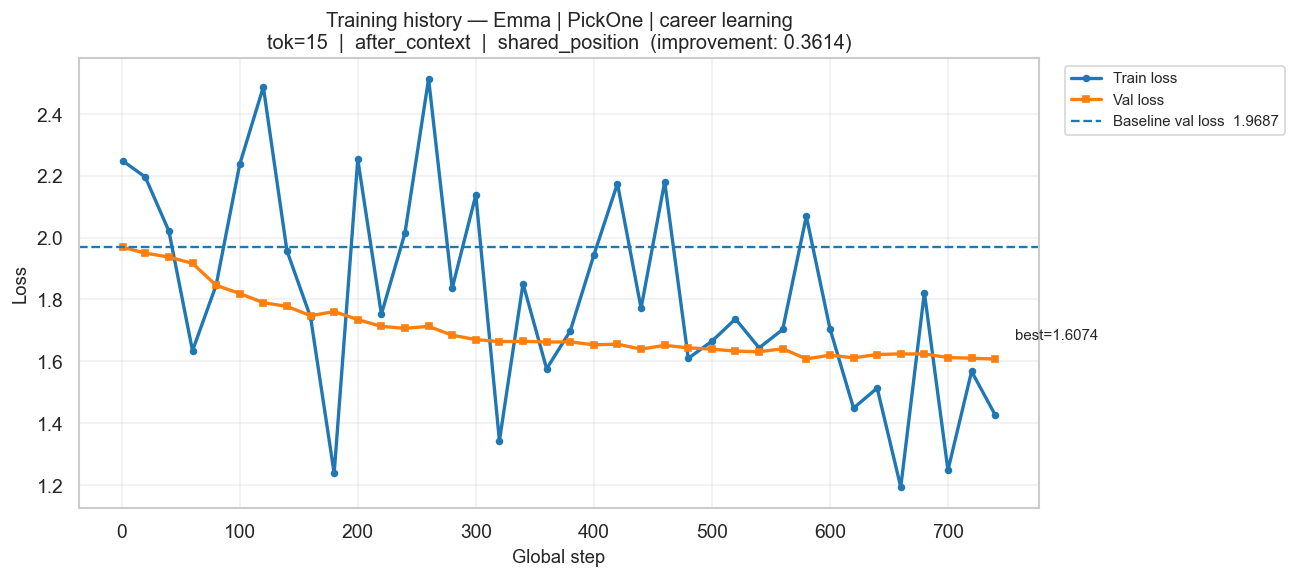

In [18]:
plot_training_history(
    df_history,
    persona            = 'Emma',
    style              = 'PickOne',
    held_out_topic     = 'career_learning',
    token_placement    = 'after_context',
    position_mode      = 'shared_position',
    num_special_tokens = 15,
)

## 9. Plot 4 — Token-Count Trend

**Slide 4** — Why tok15? Mean best val loss vs token count for one branch, with the flat baseline as a dashed reference. Any point below the dashed line is an improvement.

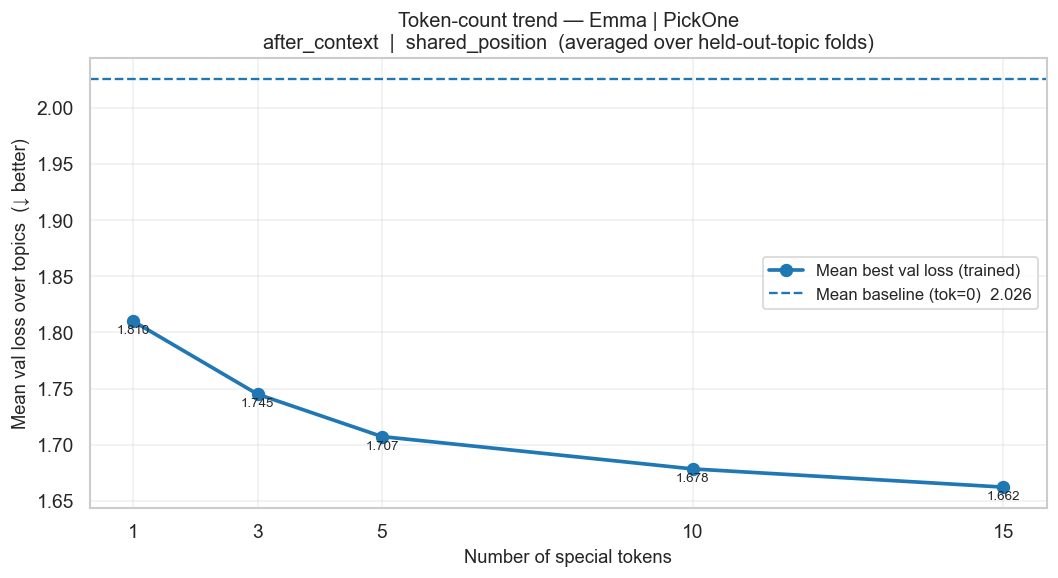

In [19]:
plot_token_count_trend(
    df_paired,
    persona         = 'Emma',
    style           = 'PickOne',
    token_placement = 'after_context',
    position_mode   = 'shared_position',
)

## 10. Sweep All Branches

Plot 2 and Plot 4 for every (persona, style) combination.


  Emma | PickOne


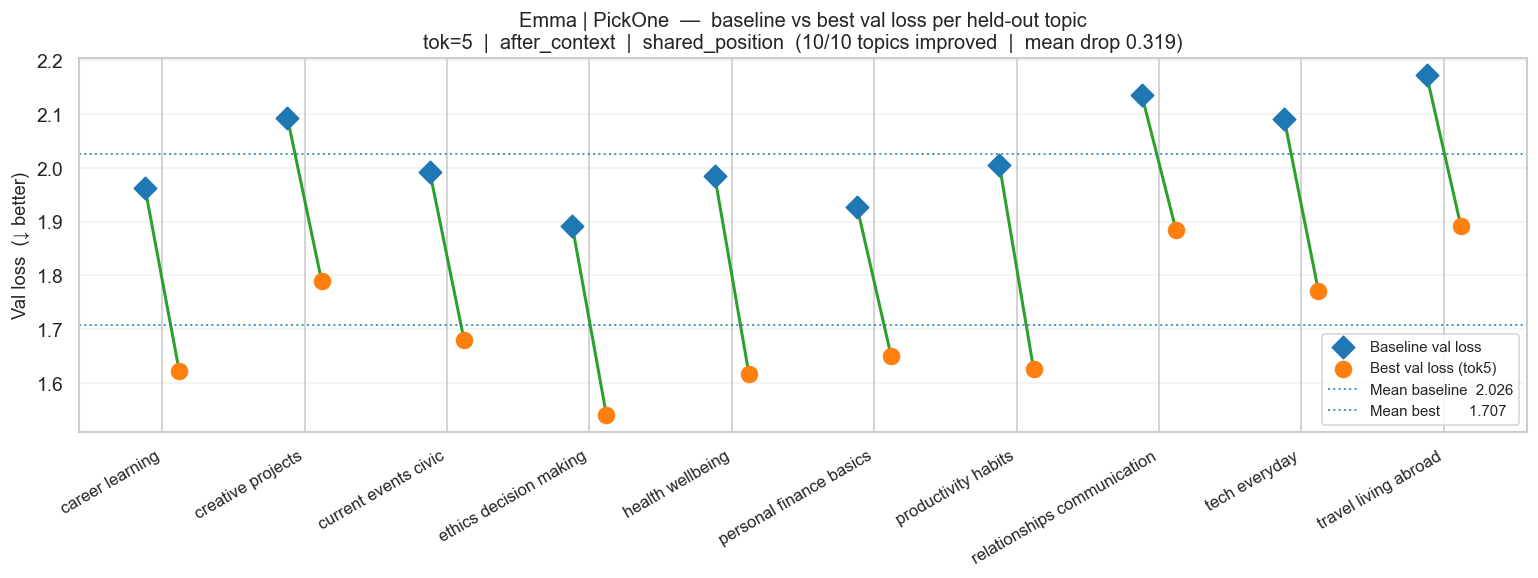

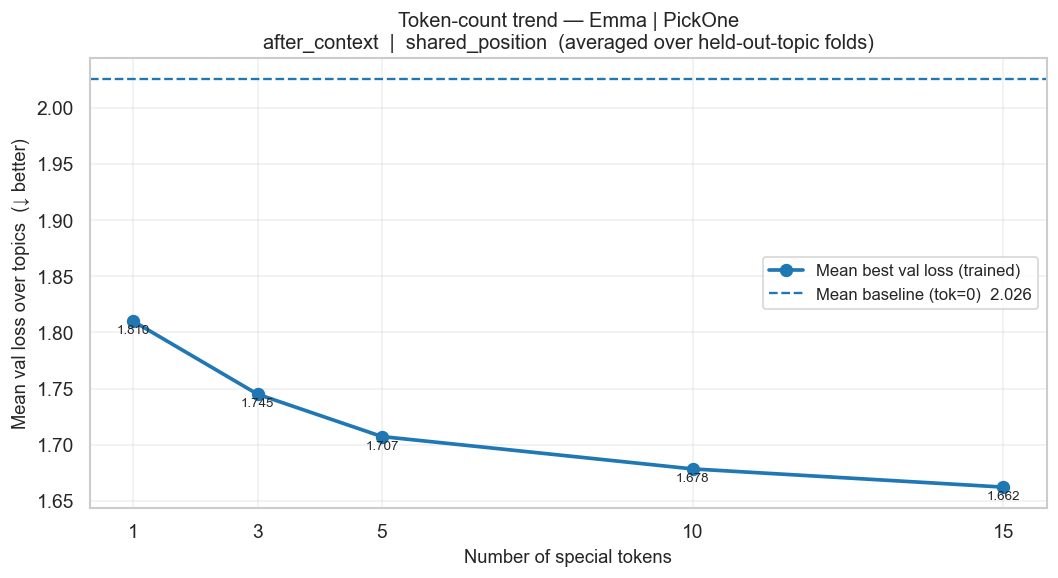


  Emma | SoBasically


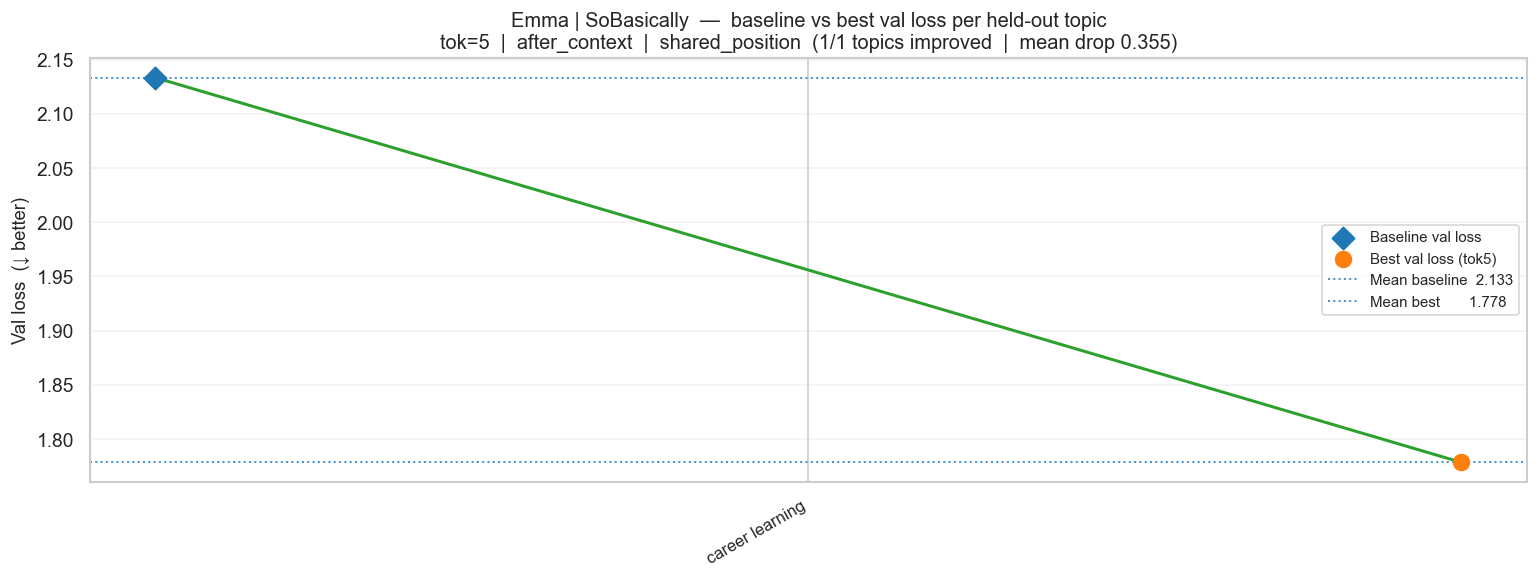

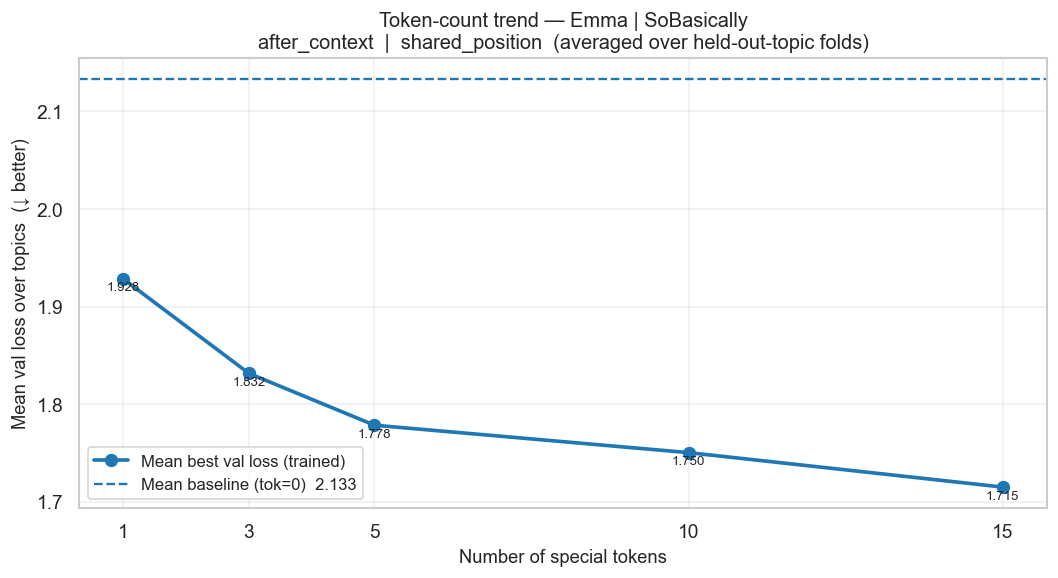


  Emma | WhatIf


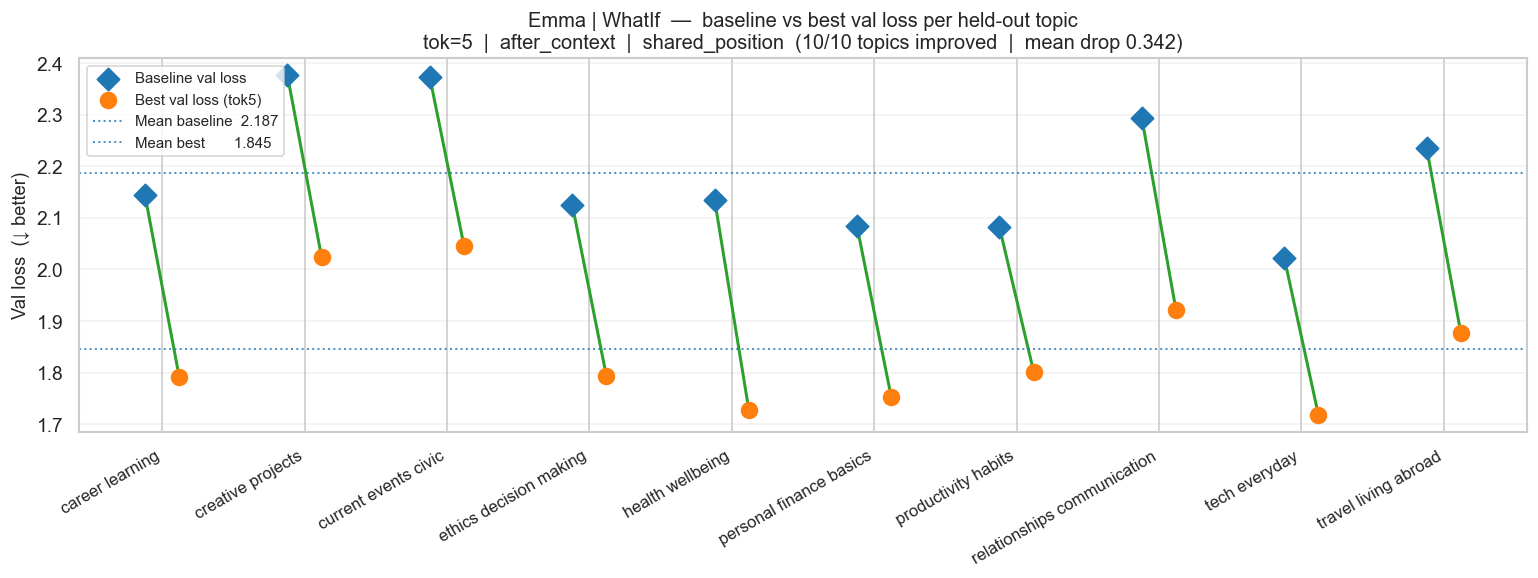

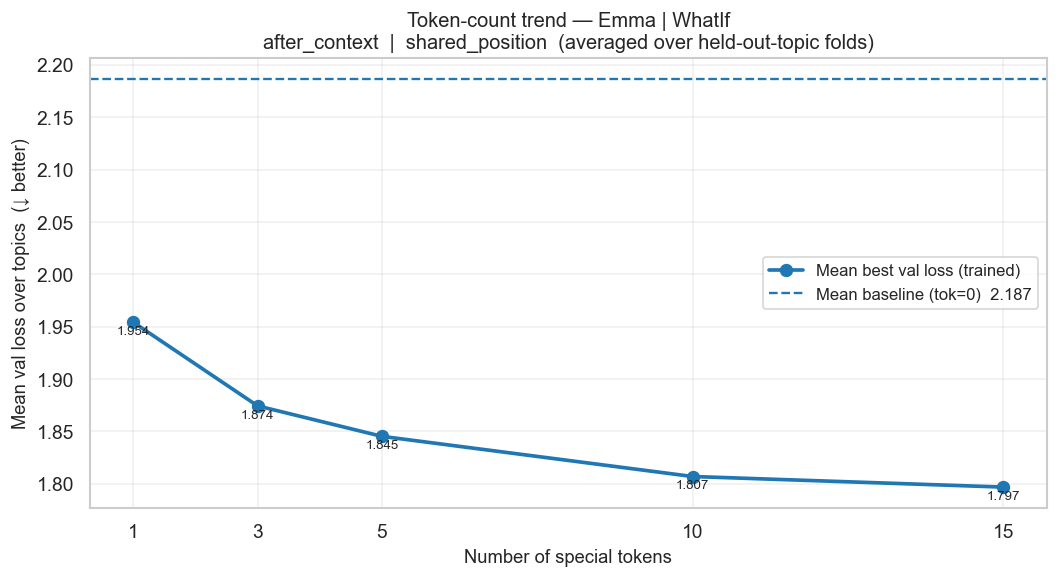


  Maria | PickOne


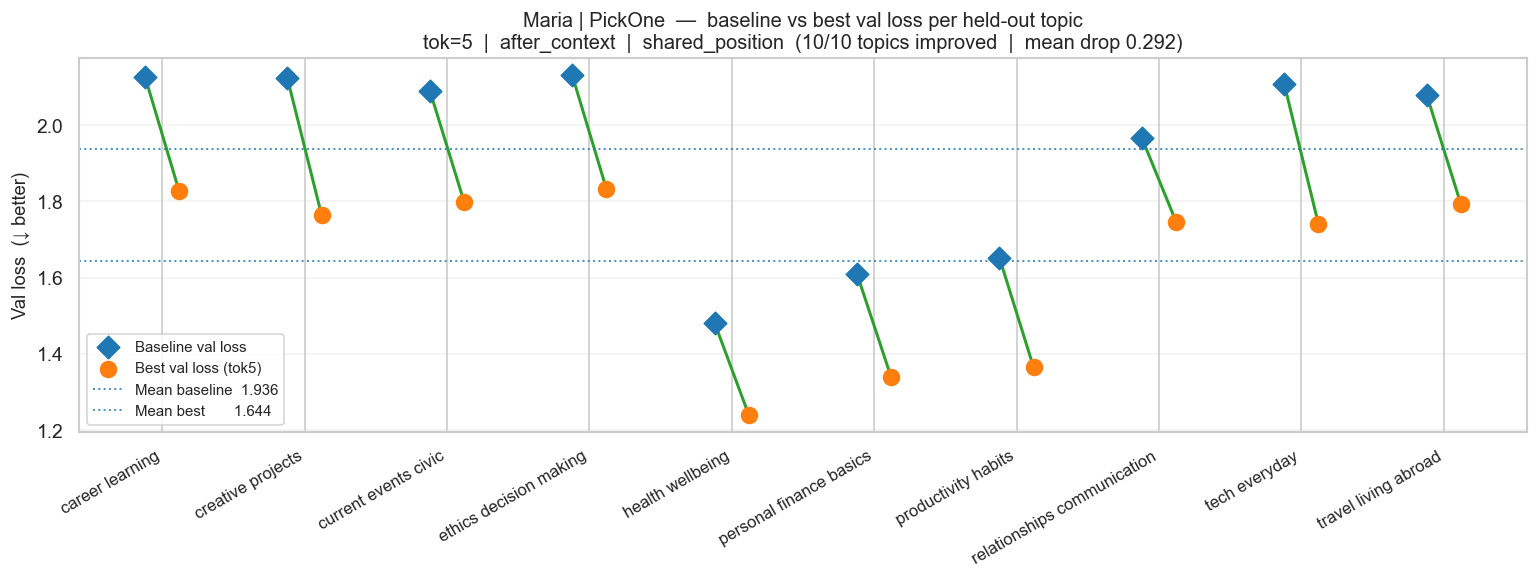

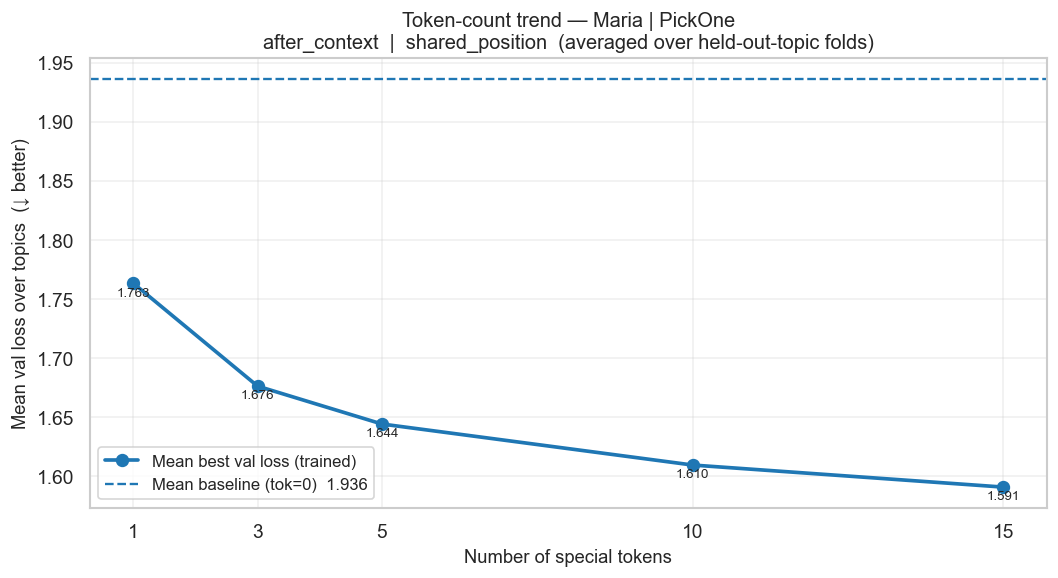


  Maria | WhatIf


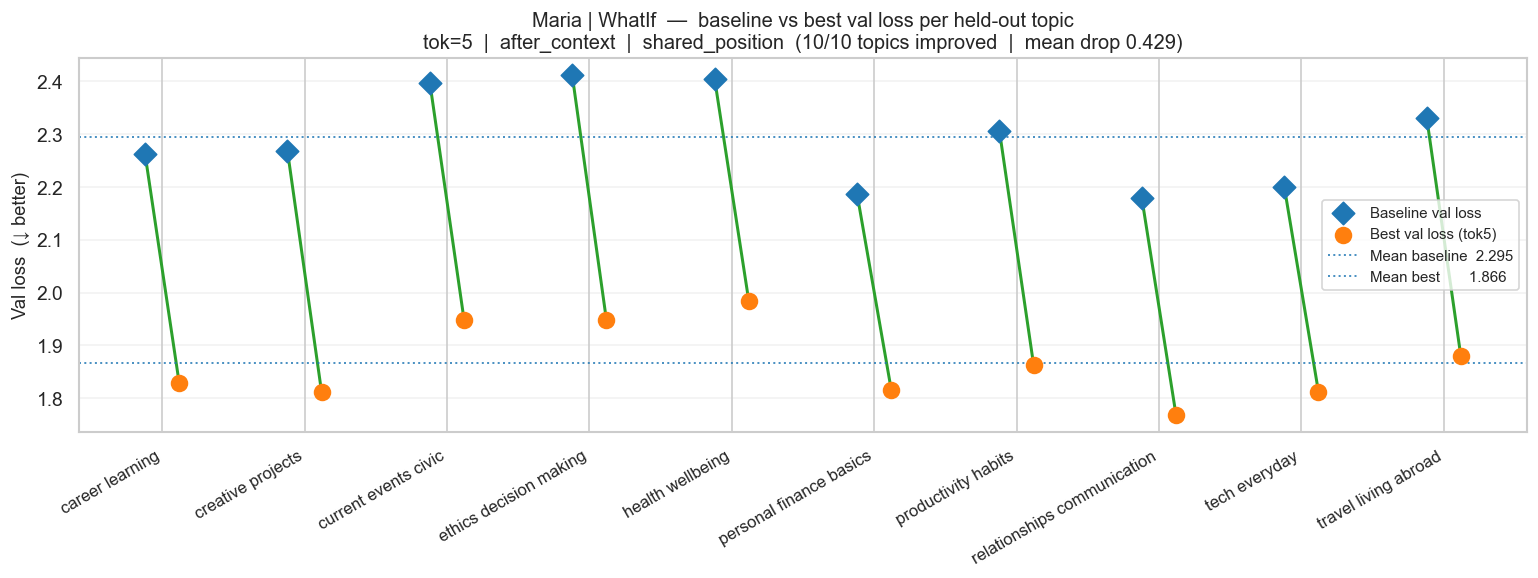

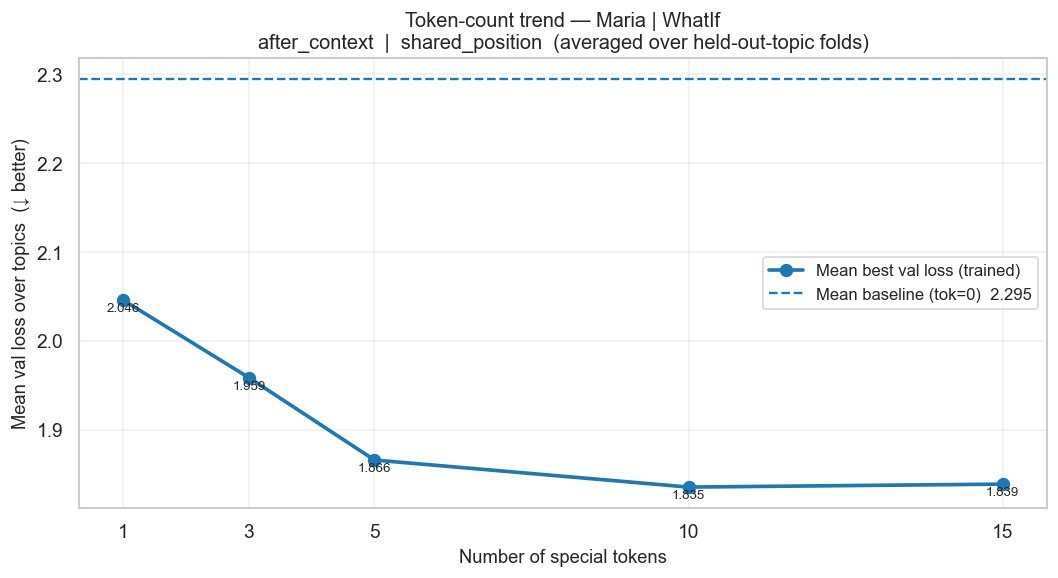

In [21]:
PLACEMENT = 'after_context'
POS_MODE  = 'shared_position'
N_TOKENS  = 5

branches = sorted(df_paired[['base_persona_id', 'style_id']].drop_duplicates().itertuples(index=False))
for persona, style in branches:
    print(f'\n{"="*60}\n  {persona} | {style}\n{"="*60}')
    plot_topics_for_branch(
        df_paired, persona=persona, style=style,
        token_placement=PLACEMENT, position_mode=POS_MODE, num_special_tokens=N_TOKENS,
    )
    plot_token_count_trend(
        df_paired, persona=persona, style=style,
        token_placement=PLACEMENT, position_mode=POS_MODE,
    )